<a href="https://colab.research.google.com/github/naufalaqill55/-project-cnn-vs-transfer-learning/blob/main/CNN_Scratch_vs_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Load Dataset CIFAR-10 (Otomatis terunduh)
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalisasi piksel ke skala 0 - 1
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# Split Validation Data (80% Train, 20% Val)
val_size = int(len(x_train_full) * 0.2)
x_val, y_val = x_train_full[:val_size], y_train_full[:val_size]
x_train, y_train = x_train_full[val_size:], y_train_full[val_size:]

# 2. Bikin Arsitektur CNN Sederhana
model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.5), # Biar nggak terlalu overfitting
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 kelas CIFAR-10
])

# 3. Compile & Fit (Training)
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_cnn = model_cnn.fit(x_train, y_train,
                            epochs=15,
                            batch_size=64,
                            validation_data=(x_val, y_val))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1266s 7us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3581 - loss: 1.7228 - val_accuracy: 0.4830 - val_loss: 1.4137
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4987 - loss: 1.3818 - val_accuracy: 0.5602 - val_loss: 1.2225
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5488 - loss: 1.2522 - val_accuracy: 0.6081 - val_loss: 1.1243
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5913 - loss: 1.1508 - val_accuracy: 0.6331 - val_loss: 1.0419
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6191 - loss: 1.0794 - val_accuracy: 0.6551 - val_loss: 0.9807
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6371 - loss: 1.0287 - val_accuracy: 0.6600 - val_loss: 0.9668
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6527 - loss: 0.9822 - val_accuracy: 0.6694 - val_loss: 0.9371
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6724 - loss: 0.9309 - val_accuracy: 0

In [12]:
import os
import glob
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Unduh dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
extracted_path = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

# Cari otomatis folder tempat subfolder 'roses' berada
roses_dirs = glob.glob(os.path.join(os.path.dirname(extracted_path), '**', 'roses'), recursive=True)
if roses_dirs:
    data_dir = os.path.dirname(roses_dirs[0])
else:
    data_dir = extracted_path

print(f"Path dataset yang ditemukan: {data_dir}")

IMG_SIZE = (160, 160)
BATCH_SIZE = 32

# Load 2 kelas (roses vs tulips)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=['roses', 'tulips']
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=['roses', 'tulips']
)

# Normalisasi piksel ke [-1, 1] untuk MobileNetV2
rescale = layers.Rescaling(1./127.5, offset=-1)
train_ds = train_ds.map(lambda x, y: (rescale(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (rescale(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)

# 2. Transfer Learning (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# 3. Compile & Fit
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_tl = model_tl.fit(train_ds, epochs=5, validation_data=val_ds)

Path dataset yang ditemukan: /root/.keras/datasets/flower_photos/flower_photos
Found 1440 files belonging to 2 classes.
Using 1152 files for training.
Found 1440 files belonging to 2 classes.
Using 288 files for validation.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 188ms/step - accuracy: 0.4609 - loss: 0.9340 - val_accuracy: 0.4757 - val_loss: 0.8126
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.5330 - loss: 0.8146 - val_accuracy: 0.5694 - val_loss: 0.7175
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.5833 - loss: 0.7222 - val_accuracy: 0.6285 - val_loss: 0.6373
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6311 - loss: 0.6598 - val_accuracy: 0.6632 - val_loss: 0.5766
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.6597 - loss: 0.6029 - val_accuracy: 0.7118 - val_loss: 0.5280


=== GRAFIK PERFORMA CNN SCRATCH (CIFAR-10) ===


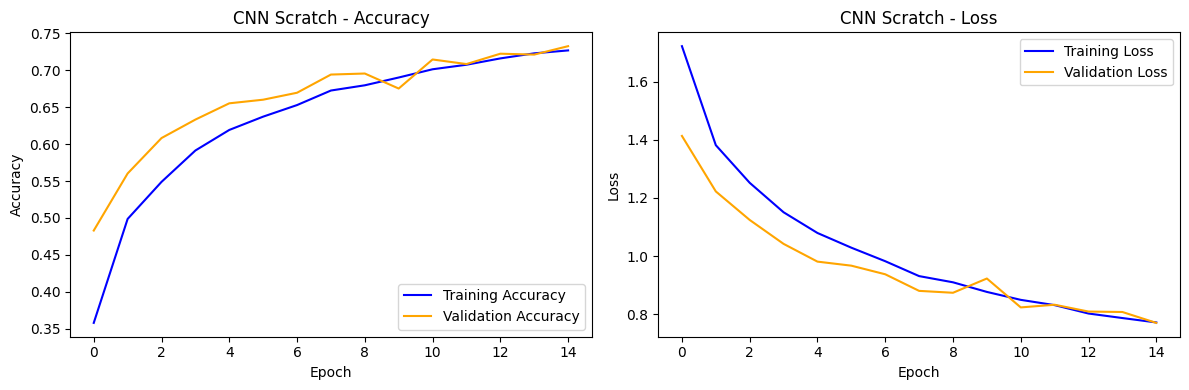


=== GRAFIK PERFORMA TRANSFER LEARNING (MobileNetV2) ===


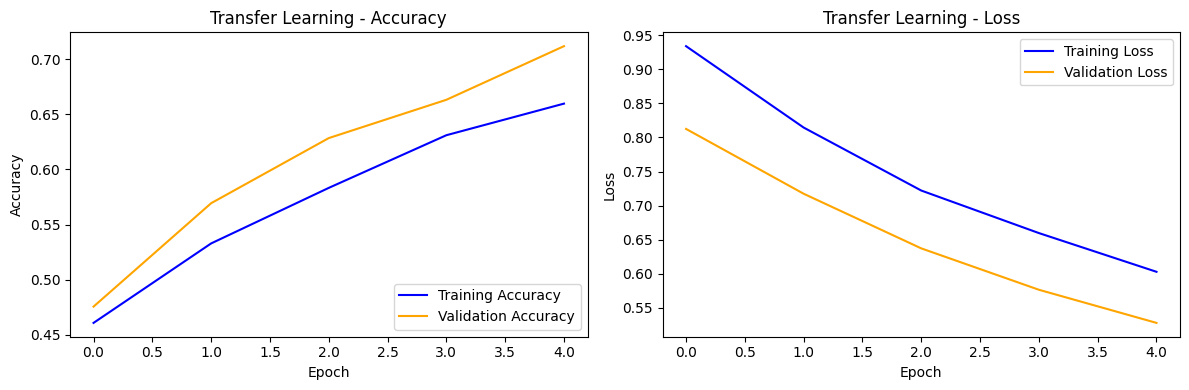


RINGKASAN PARAMETER MODEL CNN SCRATCH


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 367,712 (1.40 MB)

 Trainable params: 122,570 (478.79 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,829 (8.63 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2,564 (10.02 KB)

In [13]:
import matplotlib.pyplot as plt

# 1. Fungsi Visualisasi Performa Model
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.tight_layout()
    plt.show()

# Tampilkan Grafik Performa Kedua Model
print("=== GRAFIK PERFORMA CNN SCRATCH (CIFAR-10) ===")
plot_history(history_cnn, "CNN Scratch")

print("\n=== GRAFIK PERFORMA TRANSFER LEARNING (MobileNetV2) ===")
plot_history(history_tl, "Transfer Learning")

# 2. Ringkasan Parameter Kedua Model
print("\n" + "="*50)
print("RINGKASAN PARAMETER MODEL CNN SCRATCH")
print("="*50)
model_cnn.summary()

print("\n" + "="*50)
print("RINGKASAN PARAMETER MODEL TRANSFER LEARNING")
print("="*50)
model_tl.summary()